# Comparaison culture majoritaire : ADONIS vs RPG 2024

Pour chaque commune de la BDD ADONIS, on compare :
- `c_maj` / `cod_c_maj` : culture majoritaire selon ADONIS (IFT 2022)
- `c_maj_rpg` / `cod_c_maj_rpg` : culture majoritaire selon le RPG 2024 (surface la plus grande)

In [47]:
# Import des bibliothèques nécessaires
from pathlib import Path
import polars as pl
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

from config import code_region_rpg
DATA_DIR = Path("../../data")
PARQUET_DIR = DATA_DIR / "parquet"

In [48]:
# Choix de la region
region = "Pays de la Loire" # ou None pour le RPG national
code = code_region_rpg[region] if region else "national"
code

'52'

## 1. Chargement des données

### Fichier ADONIS

In [49]:
# Chargement du fichier IFT ADONIS 2022 - Echelle commune
ift = pd.read_csv(
    "./../../data/raw/fre-324510908-adonis-ift-2022-v04112024.csv",
    sep=";", low_memory=False, index_col=0
)
print(ift.shape)
ift.head()

(34938, 21)


,id,nom,nom_m,insee_com,sau,sau_bio,cod_c_maj,cod_c_hbc,cod_c_h,c_maj,...,c_ift_h,ift_t,ift_t_hbc,ift_h,ift_t_hh,ift_hh_hbc,iftbc,p_bio,p_bc,p_sau
0,COMMUNE_0000000009750236,L'Abergement-Clémenciat,L'ABERGEMENT-CLEMENCIAT,01001,945.68,30.16,MIS,BTH,MIS,Maïs,...,Maïs,2.30,2.25,0.99,1.32,1.27,0.05,3.19,2.10,60.54
1,COMMUNE_0000000009750692,L'Abergement-de-Varey,L'ABERGEMENT-DE-VAREY,01002,158.10,23.93,PPH,Vigne,Vigne,Prairie permanente,...,Vigne,0.50,0.39,0.02,0.48,0.37,0.11,15.14,21.43,17.23
2,COMMUNE_0000000009750944,Ambérieu-en-Bugey,AMBERIEU-EN-BUGEY,01004,181.57,81.76,PPH,MIS,MIS,Prairie permanente,...,Maïs,0.58,0.56,0.26,0.33,0.30,0.02,45.03,4.28,7.41
3,COMMUNE_0000000009750958,Ambérieux-en-Dombes,AMBERIEUX-EN-DOMBES,01005,1017.84,NaN,MIS,BTH,MIS,Maïs,...,Maïs,2.30,2.26,1.05,1.23,1.21,0.04,NaN,1.71,63.56
4,COMMUNE_0000000009751732,Ambléon,AMBLEON,01006,125.88,29.54,PPH,BTH,BTH,Prairie permanente,...,Blé tendre,0.22,0.21,0.09,0.13,0.12,0.00,23.47,1.98,20.87


In [50]:
ift_epci = pl.read_parquet(PARQUET_DIR / "ift_cult_top3_epci.parquet")
ift_epci.head()

codes_siren_des_epci,nom_epci,c_maj_1,c_maj_2,c_maj_3,cod_c_maj_1,cod_c_maj_2,cod_c_maj_3,sau_c_maj_1,sau_c_maj_2,sau_c_maj_3
str,str,str,str,str,str,str,str,f64,f64,f64
"""200071587""","""CC Loches Sud Touraine""","""Blé tendre""","""Prairie en rotation longue (6 …","""Prairie permanente""","""BTH""","""PRL""","""PPH""",112398.18,3001.93,1015.74
"""200067106""","""CA du Pays Basque""","""Prairie permanente""","""Surface pastorale (SPH)""","""Surface pastorale (SPL)""","""PPH""","""SPH""","""SPL""",104142.06,39417.59,18164.67
"""200066660""","""CC Saint-Flour Communauté""","""Prairie permanente""","""Prairie en rotation longue (6 …",null,"""PPH""","""PRL""",null,91231.65,536.02,null
"""200069755""","""CC Mellois en Poitou""","""Blé tendre""","""Prairie permanente""",null,"""BTH""","""PPH""",null,88981.51,3283.69,null
"""200067205""","""CA du Cotentin""","""Prairie permanente""","""Chou""","""Maïs ensilage""","""PPH""","""CHU""","""MIE""",84446.72,2490.41,1729.79


### Données spatialisées

In [51]:
# Choix des paramètres
annee = 2022 # ou 2024
zone = "commune" # ou "epci" ou "commune"


In [52]:
# Récupération du fichier RPG correspondant
file = f"rpg_{zone}_{annee}_df.parquet"
print(f"Fichier sélectionné : {file}")
df = pl.read_parquet(PARQUET_DIR / file)
print(f"Fichier RPG chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Fichier sélectionné : rpg_commune_2022_df.parquet
Fichier RPG chargé : 1341 lignes, 15 colonnes


In [53]:
# Nom de la colonne d'identification et de la colonne de nom selon la zone
col_name = f"nom_{zone}"
if zone == "commune":
    code_rpg = "code_insee"
    code_ift = "insee_com"
    col_zone = "nom_commune"
    ift = pl.from_pandas(ift)
elif zone == "epci":
    code_rpg = "code_siren"
    code_ift = "codes_siren_des_epci"
    col_zone = "nom_epci"
    ift = ift_epci
else:
    raise ValueError("Zone non supportée")

## 2. Jointure ADONIS vs RPG


In [54]:
print(ift.columns)
print(df.columns)

['id', 'nom', 'nom_m', 'insee_com', 'sau', 'sau_bio', 'cod_c_maj', 'cod_c_hbc', 'cod_c_h', 'c_maj', 'c_ift_hbc', 'c_ift_h', 'ift_t', 'ift_t_hbc', 'ift_h', 'ift_t_hh', 'ift_hh_hbc', 'iftbc', 'p_bio', 'p_bc', 'p_sau']
['nom_commune', 'code_insee', 'SAU_tot', 'nb_parc', 'nb_cult', 'cult_maj', 'code_cultu_1', 'code_cultu_2', 'code_cultu_3', 'SAU_cult_1', 'SAU_cult_2', 'SAU_cult_3', 'pct_SAU_1', 'pct_SAU_2', 'pct_SAU_3']


In [55]:
# Jointure ADONIS + RPG
ift_rpg = ift.join(
        df, left_on=code_ift, right_on=code_rpg, how="right")
ift_rpg.head()

id,nom,nom_m,sau,sau_bio,cod_c_maj,cod_c_hbc,cod_c_h,c_maj,c_ift_hbc,c_ift_h,ift_t,ift_t_hbc,ift_h,ift_t_hh,ift_hh_hbc,iftbc,p_bio,p_bc,p_sau,nom_commune,code_insee,SAU_tot,nb_parc,nb_cult,cult_maj,code_cultu_1,code_cultu_2,code_cultu_3,SAU_cult_1,SAU_cult_2,SAU_cult_3,pct_SAU_1,pct_SAU_2,pct_SAU_3
str,str,str,f64,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,u32,u32,str,str,str,str,f64,f64,f64,f64,f64,f64
"""COMMUNE_0000000009747388""","""Beauvoir-sur-Mer""","""BEAUVOIR-SUR-MER""",2141.25,347.88,"""PPH""","""BTH""","""BTH""","""Prairie permanente""","""Blé tendre""","""Blé tendre""",0.29,0.29,0.12,0.17,0.17,0.0,16.25,1.65,60.97,"""BEAUVOIR-SUR-MER""","""85018""",1744.34,549,47,"""PPH""","""PPH""","""BTH""","""LUZ""",1312.64,83.0,66.99,75.251384,4.758247,3.840421
"""COMMUNE_0000000009746378""","""Vertou""","""VERTOU""",805.29,231.98,"""Vigne""","""Vigne""","""Vigne""","""Vigne""","""Vigne""","""Vigne""",5.15,4.02,0.36,4.8,3.66,1.13,28.81,21.98,21.14,"""VERTOU""","""44215""",580.2,424,22,"""VRC""","""VRC""","""PPH""","""PTR""",252.27,124.0,62.09,43.479835,21.371941,10.701482
"""COMMUNE_0000000009739826""","""Saint-Loup-du-Gast""","""SAINT-LOUP-DU-GAST""",741.68,null,"""MIE""","""BTH""","""MIE""","""Maïs ensilage""","""Blé tendre""","""Maïs ensilage""",2.12,2.11,1.01,1.11,1.1,0.01,null,0.35,74.1,"""SAINT-LOUP-DU-GAST""","""53234""",604.11,285,16,"""MIE""","""MIE""","""BTH""","""PPH""",164.87,115.58,114.4,27.291387,19.132277,18.936949
"""COMMUNE_0000000009741985""","""Fatines""","""FATINES""",344.96,null,"""PPH""","""MIS""","""MIE""","""Prairie permanente""","""Maïs""","""Maïs ensilage""",1.51,1.49,0.8,0.71,0.69,0.02,null,1.33,63.21,"""FATINES""","""72129""",262.62,109,17,"""MIE""","""MIE""","""MIS""","""PPH""",65.78,59.78,56.92,25.047597,22.762927,21.673901
"""COMMUNE_0000000009741678""","""Saint-Maixent""","""SAINT-MAIXENT""",1441.04,91.79,"""PPH""","""BTH""","""BTH""","""Prairie permanente""","""Blé tendre""","""Blé tendre""",1.9,1.88,0.87,1.03,1.02,0.01,6.37,0.71,64.33,"""SAINT-MAIXENT""","""72296""",1123.18,350,28,"""PPH""","""PPH""","""BTH""","""MIE""",275.34,219.56,175.99,24.514325,19.548069,15.668904


## 3. Analyse

In [56]:
# Selection des variables d'intérêt
if zone == "commune":
    culture_ift = "cod_c_maj"
else:
    culture_ift = "cod_c_maj_1"

In [57]:
ift_rpg.head(4)

id,nom,nom_m,sau,sau_bio,cod_c_maj,cod_c_hbc,cod_c_h,c_maj,c_ift_hbc,c_ift_h,ift_t,ift_t_hbc,ift_h,ift_t_hh,ift_hh_hbc,iftbc,p_bio,p_bc,p_sau,nom_commune,code_insee,SAU_tot,nb_parc,nb_cult,cult_maj,code_cultu_1,code_cultu_2,code_cultu_3,SAU_cult_1,SAU_cult_2,SAU_cult_3,pct_SAU_1,pct_SAU_2,pct_SAU_3
str,str,str,f64,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,u32,u32,str,str,str,str,f64,f64,f64,f64,f64,f64
"""COMMUNE_0000000009747388""","""Beauvoir-sur-Mer""","""BEAUVOIR-SUR-MER""",2141.25,347.88,"""PPH""","""BTH""","""BTH""","""Prairie permanente""","""Blé tendre""","""Blé tendre""",0.29,0.29,0.12,0.17,0.17,0.0,16.25,1.65,60.97,"""BEAUVOIR-SUR-MER""","""85018""",1744.34,549,47,"""PPH""","""PPH""","""BTH""","""LUZ""",1312.64,83.0,66.99,75.251384,4.758247,3.840421
"""COMMUNE_0000000009746378""","""Vertou""","""VERTOU""",805.29,231.98,"""Vigne""","""Vigne""","""Vigne""","""Vigne""","""Vigne""","""Vigne""",5.15,4.02,0.36,4.8,3.66,1.13,28.81,21.98,21.14,"""VERTOU""","""44215""",580.2,424,22,"""VRC""","""VRC""","""PPH""","""PTR""",252.27,124.0,62.09,43.479835,21.371941,10.701482
"""COMMUNE_0000000009739826""","""Saint-Loup-du-Gast""","""SAINT-LOUP-DU-GAST""",741.68,null,"""MIE""","""BTH""","""MIE""","""Maïs ensilage""","""Blé tendre""","""Maïs ensilage""",2.12,2.11,1.01,1.11,1.1,0.01,null,0.35,74.1,"""SAINT-LOUP-DU-GAST""","""53234""",604.11,285,16,"""MIE""","""MIE""","""BTH""","""PPH""",164.87,115.58,114.4,27.291387,19.132277,18.936949
"""COMMUNE_0000000009741985""","""Fatines""","""FATINES""",344.96,null,"""PPH""","""MIS""","""MIE""","""Prairie permanente""","""Maïs""","""Maïs ensilage""",1.51,1.49,0.8,0.71,0.69,0.02,null,1.33,63.21,"""FATINES""","""72129""",262.62,109,17,"""MIE""","""MIE""","""MIS""","""PPH""",65.78,59.78,56.92,25.047597,22.762927,21.673901


In [58]:
# Ajout d'une colonne de comparaison entre les codes majoritaires ADONIS et RPG
ift_rpg = ift_rpg.with_columns(
        (pl.col("code_cultu_1") == pl.col(culture_ift)).alias("match_code_majoritaire"),
    )

In [59]:
# BILAN
print(f"Total communes ADONIS : {ift_rpg.shape[0]}")
print(f"Communes avec données RPG : {ift_rpg['code_cultu_1'].drop_nulls().shape[0]}")
print(f"Communes avec match exact (code) : {ift_rpg['match_code_majoritaire'].sum()}")
print(f"Taux de correspondance avec culture 1(code) : {ift_rpg['match_code_majoritaire'].mean():.1%}")
print(f"Communes avec données ift : {ift_rpg[culture_ift].drop_nulls().shape[0]}")
print(f"Nombre de codes majoritaires ADONIS différents : {ift_rpg[culture_ift].n_unique()}")
print(f"Nombre de codes culture majoritaires RPG différents : {ift_rpg['code_cultu_1'].n_unique()}")


Total communes ADONIS : 1341
Communes avec données RPG : 1341
Communes avec match exact (code) : 1106
Taux de correspondance avec culture 1(code) : 82.5%
Communes avec données ift : 1340
Nombre de codes majoritaires ADONIS différents : 18
Nombre de codes culture majoritaires RPG différents : 28


In [60]:
# Heatmap des correspondances ADONIS vs RPG
heat_df = ift_rpg.filter(
    pl.col("code_cultu_1").is_not_null()
).select([culture_ift, "code_cultu_1"]).to_pandas()

heat = pd.crosstab(heat_df[culture_ift], heat_df["code_cultu_1"])
heat_norm = pd.crosstab(
    heat_df[culture_ift], 
    heat_df["code_cultu_1"],
    normalize="index"  # % par ligne (par cod_c_maj)
) * 100


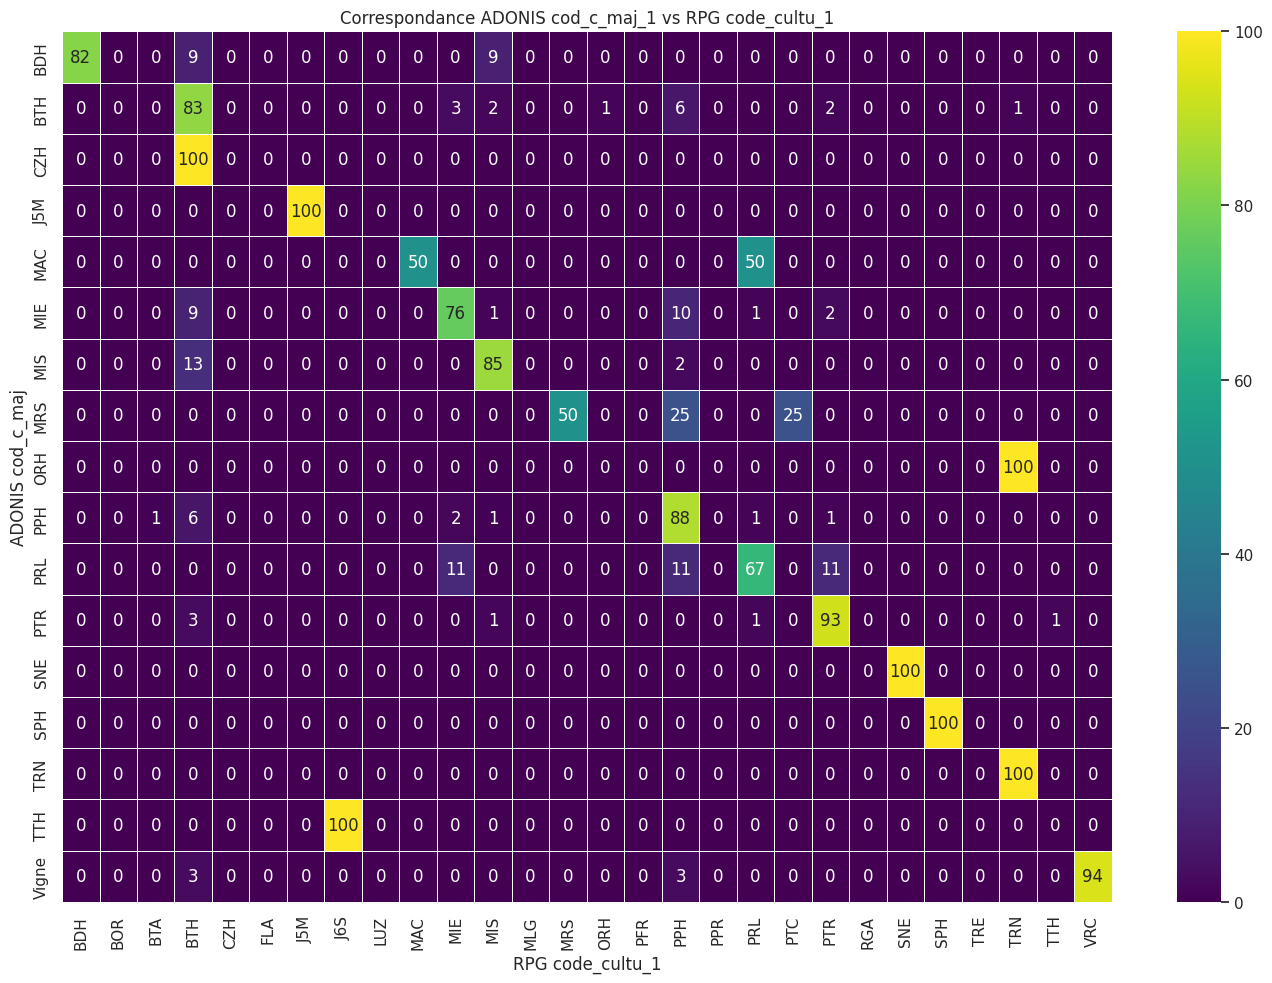

In [61]:
# Heatmap des correspondances en % de chaque code majoritaire ADONIS
plt.figure(figsize=(14, 10))
sns.heatmap(heat_norm, cmap="viridis", linewidths=0.5, annot=True, fmt=".0f", vmin=0, vmax=100)
plt.title("Correspondance ADONIS cod_c_maj_1 vs RPG code_cultu_1")
plt.xlabel("RPG code_cultu_1")
plt.ylabel("ADONIS cod_c_maj")
plt.tight_layout()
plt.show()

## 5. Analyse des divergences

### Mapping des cultures

In [62]:
# Nominalisation des cultures pour faciliter la comparaison
nomenclature = pd.read_excel("./../../data/raw/RPG_nomenclatures.xlsx")
nomenclature

,code_culture,libelle_culture,code_groupe,libelle_groupe
0,BTH,Blé tendre d'hiver,1,Blé tendre
1,BTP,Blé tendre de printemps,1,Blé tendre
2,MID,Maïs doux,2,Maïs grain et ensilage
3,MIE,Maïs ensilage,2,Maïs grain et ensilage
4,MIS,Maïs,2,Maïs grain et ensilage
...,...,...,...,...
343,TBT,Tubercule tropical,28,Divers
344,TCR,Taillis à courte rotation,28,Divers
345,TRU,Truffière (chênaie de plants mycorhizés),28,Divers
346,VET,Vétiver,28,Divers


In [63]:
# Merge des codes avec la nomenclature pour faciliter l'interprétation
ift_rpg = ift_rpg.with_columns(
    pl.col("code_cultu_1").cast(pl.String)
).join(
    pl.DataFrame(
        nomenclature[["code_culture", "libelle_culture"]]
        .rename(columns={"code_culture": "code_cultu_1", "libelle_culture": "lib_cultu_1"})
    ),
    on="code_cultu_1",
    how="left"
)


In [65]:
# Communes où les cultures ne correspondent pas
divergences = (
    ift_rpg
    .filter(pl.col("match_code_majoritaire") == False)
    .filter(pl.col("code_cultu_1").is_not_null())
    .select([col_zone, culture_ift, "code_cultu_1", "lib_cultu_1", ])
)

print(f"Communes avec divergence : {divergences.shape[0]}")
divergences.head(20)

Communes avec divergence : 234


nom_commune,cod_c_maj,code_cultu_1,lib_cultu_1
str,str,str,str
"""VERTOU""","""Vigne""","""VRC""","""Vigne : raisins de cuve"""
"""FATINES""","""PPH""","""MIE""","""Maïs ensilage"""
"""CELLE""","""BTH""","""MLG""","""Mélange de légumineuses prépon…"
"""EANCE""","""BTH""","""PPH""","""Prairie permanente - herbe pré…"
"""CHENAY""","""PPH""","""MIE""","""Maïs ensilage"""
…,…,…,…
"""DENAZE""","""MIE""","""BTH""","""Blé tendre d'hiver"""
"""BEAUREPAIRE""","""PPH""","""BTH""","""Blé tendre d'hiver"""
"""ERBRAY""","""BTH""","""PRL""","""Prairie en rotation longue (6 …"


In [67]:
insee = "35064"
ift.filter(pl.col("insee_com") == insee)

id,nom,nom_m,insee_com,sau,sau_bio,cod_c_maj,cod_c_hbc,cod_c_h,c_maj,c_ift_hbc,c_ift_h,ift_t,ift_t_hbc,ift_h,ift_t_hh,ift_hh_hbc,iftbc,p_bio,p_bc,p_sau
str,str,str,str,f64,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""COMMUNE_0000000009743695""","""La Chapelle-de-Brain""","""LA CHAPELLE-DE-BRAIN""","""35064""",814.18,34.92,"""BTH""","""BTH""","""BTH""","""Blé tendre""","""Blé tendre""","""Blé tendre""",2.55,2.5,1.09,1.46,1.41,0.05,4.29,2.13,45.74


In [68]:
df.filter(pl.col("code_insee") == insee)

nom_commune,code_insee,SAU_tot,nb_parc,nb_cult,cult_maj,code_cultu_1,code_cultu_2,code_cultu_3,SAU_cult_1,SAU_cult_2,SAU_cult_3,pct_SAU_1,pct_SAU_2,pct_SAU_3
str,str,f64,u32,u32,str,str,str,str,f64,f64,f64,f64,f64,f64
"""LA CHAPELLE-DE-BRAIN""","""35064""",0.07,1,1,"""PPH""","""PPH""",null,null,0.07,null,null,100.0,null,null


In [70]:
# Représentation sous forme de carte
sub = df.filter(pl.col("code_insee") == insee)
nom_commune = sub["nom_commune"].iloc[0]
fig, ax = plt.subplots(figsize=(12, 10))
sub.plot(
    column="code_cultu",
    cmap="tab20",
    legend=True,
    ax=ax,
    markersize=0.5
)
ax.set_title(f"RPG - Parcelles agricoles {nom_commune} - Code INSEE {insee} - année {annee}")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{nom_commune}.png", dpi=150)
plt.show()

AttributeError: 'Series' object has no attribute 'iloc'

In [ ]:
# Représentation sous forme de carte avec RPG 2022
df2022= rpg2022_avec_admin_pour_carte[rpg2022_avec_admin_pour_carte["code_insee"] == insee]
nom_commune = df2022["nom_commune"].iloc[0]
fig, ax = plt.subplots(figsize=(12, 10))
df2022.plot(
    column="CODE_CULTU",
    cmap="tab20",
    legend=True,
    ax=ax,
    markersize=0.5
)
ax.set_title(f"RPG - Parcelles agricoles {nom_commune} - Code INSEE {insee} - Anée 2022")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{nom_commune}.png", dpi=150)
plt.show()

## 6. Export du tableau de comparaison

In [ ]:
# Export de la comparaison
out_path = PARQUET_DIR / "compare_adonis_rpg.parquet"
compare.write_parquet(out_path)
print(f"Exporté : {out_path}")

# Aperçu du taux de match par culture ADONIS
(
    compare
    .filter(pl.col("code_cultu_1").is_not_null())
    .group_by(["cod_c_maj", "c_maj"])
    .agg([
        pl.len().alias("nb_communes"),
        pl.col("match_code_c").mean().alias("taux_match"),
    ])
    .sort("nb_communes", descending=True)
    .with_columns(pl.col("taux_match").round(2))
    .head(30)
)
